# Background of hindered rotor model and introduce how we can just get the eigenvalues for a rotational PES 

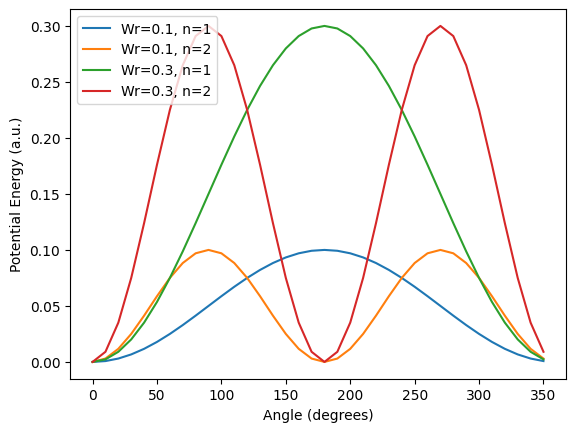

In [4]:
from JDFTxFreeNrg.qrotor import get_helmholtz, get_eigenvalues, __get_helmholtz, get_system
import matplotlib.pyplot as plt
import numpy as np
from JDFTxFreeNrg.hindered_rotor import get_HR_rot_free_energy
from scipy import constants as const

def get_HR_potential(Wr: float, n: int, angles: np.ndarray) -> np.ndarray:
    # Assumed form of the potential energy for a hindered rotor: V(θ) = Wr * (1 - cos(n*θ)) / 2
    return Wr * (1 - np.cos(np.radians(n * angles))) / 2

angles = np.arange(0, 360, 10)

for Wr in [0.1, 0.3]:
    for n in [1, 2]:
        V = get_HR_potential(Wr, n, angles)
        plt.plot(angles, V, label=f'Wr={Wr}, n={n}')
plt.xlabel('Angle (degrees)')
plt.ylabel('Potential Energy (a.u.)')
plt.legend()


# Both roughly agree for n = 1 in low barrier limit, but diverge slightly for higher barriers

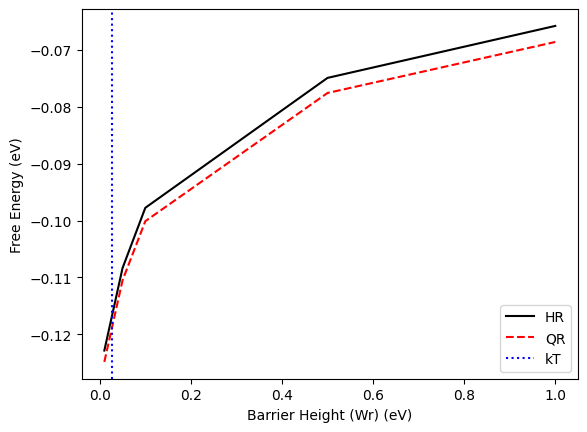

In [ ]:

n = 1
sym = 1
T = 300.
I = 150. # approximate inertia for a CO2 adsorption rotation in amu*angstrom^2
angles = np.arange(0, 360, 10)
Wrs = np.array([0.01, 0.05, 0.1, 0.5, 1.0])
As_HR = np.array([get_HR_rot_free_energy(n, Wr, I, sym, T) for Wr in Wrs])
As_QR = np.array([get_helmholtz(energies=get_HR_potential(Wr, n, angles), degrees=angles, inertia=I, T=T, sym=sym) for Wr in Wrs])

plt.plot(Wrs, As_HR, label='HR', c="black")
plt.plot(Wrs, As_QR, label='QR', c="red", linestyle="--")
plt.axvline(const.k * T / const.eV, c="blue", linestyle=":", label='kT')
plt.xlabel('Barrier Height (Wr) (eV)')
plt.ylabel('Free Energy (eV)')
plt.legend()

# Symmetry incorporated by dividing our QR partition function by the symmetry number

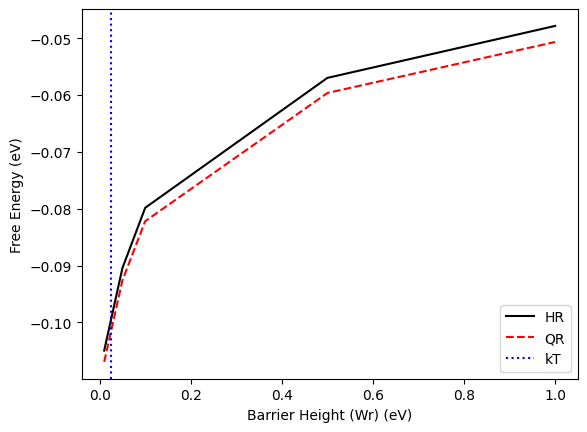

In [2]:
n = 1
sym = 2
T = 300.
I = 500. # approximate inertia for a CO2 adsorption rotation in amu*angstrom^2
angles = np.arange(0, 360, 10)
Wrs = np.array([0.01, 0.05, 0.1, 0.5, 1.0])
As_HR = np.array([get_HR_rot_free_energy(n, Wr, I, sym, T) for Wr in Wrs])
As_QR = np.array([get_helmholtz(energies=get_HR_potential(Wr, n, angles), degrees=angles, inertia=I, T=T, sym=sym) for Wr in Wrs])

plt.plot(Wrs, As_HR, label='HR', c="black")
plt.plot(Wrs, As_QR, label='QR', c="red", linestyle="--")
plt.axvline(const.k * T / const.eV, c="blue", linestyle=":", label='kT')
plt.xlabel('Barrier Height (Wr) (eV)')
plt.ylabel('Free Energy (eV)')
plt.legend()

# Diverge for n > 1 as HR assumes only one "well" is occupied in harmonic-oscillator limit (degenerate eigenvalues discarded), while our approach using qrotor assumes our rotator is not confined to any one well

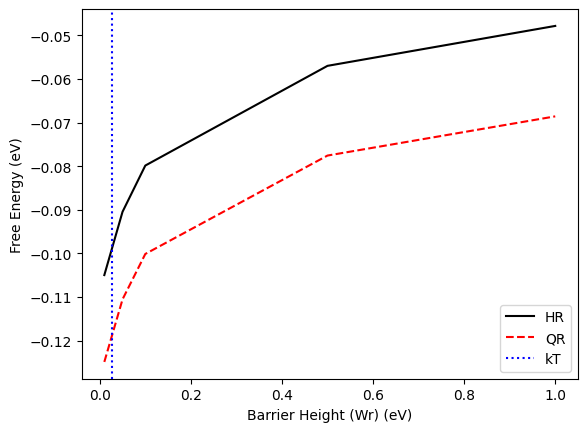

In [9]:
n = 2
sym = 1
T = 300.
I = 500. # approximate inertia for a CO2 adsorption rotation in amu*angstrom^2
angles = np.arange(0, 360, 10)
Wrs = np.array([0.01, 0.05, 0.1, 0.5, 1.0])
As_HR = np.array([get_HR_rot_free_energy(n, Wr, I, sym, T) for Wr in Wrs])
As_QR = np.array([get_helmholtz(energies=get_HR_potential(Wr, n, angles), degrees=angles, inertia=I, T=T, sym=sym) for Wr in Wrs])

plt.plot(Wrs, As_HR, label='HR', c="black")
plt.plot(Wrs, As_QR, label='QR', c="red", linestyle="--")
plt.axvline(const.k * T / const.eV, c="blue", linestyle=":", label='kT')
plt.xlabel('Barrier Height (Wr) (eV)')
plt.ylabel('Free Energy (eV)')
plt.legend()

# This degeneracy can be discarded from our qrotor model for this potential if we only use the eigenvalues of multiples of n, but relying on this technique removes the generalization the qrotor applies to non-sinusoidal potential, and I am not sure if these degeneracies should even be removed in the first place

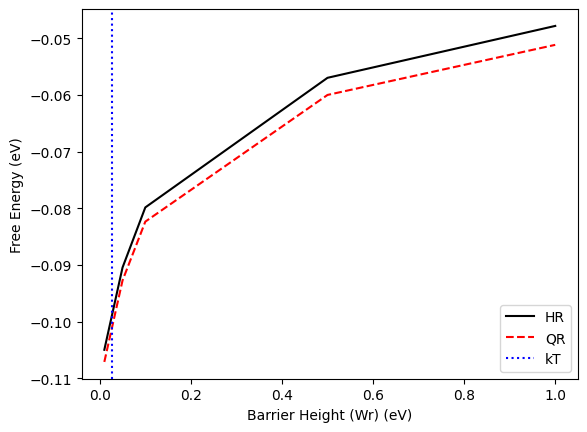

In [6]:
n = 2
sym = 1
T = 300.
I = 500. # approximate inertia for a CO2 adsorption rotation in amu*angstrom^2
angles = np.arange(0, 360, 10)
Wrs = np.array([0.01, 0.05, 0.1, 0.5, 1.0])
As_HR = np.array([get_HR_rot_free_energy(n, Wr, I, sym, T) for Wr in Wrs])
As_QR = np.array([__get_helmholtz(get_eigenvalues(get_system(get_HR_potential(Wr, n, angles), angles, I))[::n]) for Wr in Wrs])

plt.plot(Wrs, As_HR, label='HR', c="black")
plt.plot(Wrs, As_QR, label='QR', c="red", linestyle="--")
plt.axvline(const.k * T / const.eV, c="blue", linestyle=":", label='kT')
plt.xlabel('Barrier Height (Wr) (eV)')
plt.ylabel('Free Energy (eV)')
plt.legend()